# Figure 1. ExposoGraph 2.0 computational architecture

This notebook renders a manuscript-style architecture diagram for the current ExposoGraph repository state. It pulls the bundled reference-graph counts and curated source manifest directly from the package so the figure text stays aligned with the codebase.


In [7]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle

from ExposoGraph.example_graphs import build_reference_architecture_summary
from ExposoGraph.reference_data import CURATION_SOURCE_MANIFEST

summary = build_reference_architecture_summary()
primary_sources = list(CURATION_SOURCE_MANIFEST["primary_sources"])
supporting_sources = list(CURATION_SOURCE_MANIFEST["supporting_sources"])

_cwd = Path.cwd()
output_dir = (_cwd / "figures") if _cwd.name == "manuscript" else (_cwd / "manuscript/figures")
output_dir.mkdir(parents=True, exist_ok=True)

summary


ArchitectureSummary(node_count=212, edge_count=313, node_type_count=5, edge_type_count=8, node_type_counts={'Carcinogen': 56, 'Enzyme': 58, 'Metabolite': 59, 'DNA_Adduct': 27, 'Pathway': 12}, edge_type_counts={'ACTIVATES': 104, 'DETOXIFIES': 47, 'TRANSPORTS': 9, 'FORMS_ADDUCT': 37, 'REPAIRS': 25, 'PATHWAY': 88, 'INDUCES': 2, 'INHIBITS': 1}, carcinogens=('17beta-Estradiol', '2,3,4,7,8-PeCDF', '4-Aminobiphenyl', '4-Hydroxynonenal (4-HNE)', '5a-DHT', 'Acetaldehyde', 'Acrolein', 'Acrylamide', 'Aflatoxin B1', 'Arsenic (inorganic)', 'Benzene', 'Benzidine', 'Benzo[a]pyrene', 'Beryllium', 'Busulfan', 'Cadmium', 'Chlorambucil', 'Chlordane (technical)', 'Chromium (VI)', 'Crotonaldehyde', 'Cyclophosphamide', 'DDT', 'DMBA', 'Ethanol', 'Ethylene Oxide', 'Formaldehyde', 'Furfural', 'Glycidamide', 'Heptachlor', 'Hexachlorobenzene (HCB)', 'Lindane (γ-HCH)', 'MNU (N-methyl-N-nitrosourea)', 'Malondialdehyde (MDA)', 'MeIQx', 'NDEA', 'NDMA', 'NNK', 'Nickel compounds', 'PCB 118', 'PCB 126', 'PCB 138', 'PCB

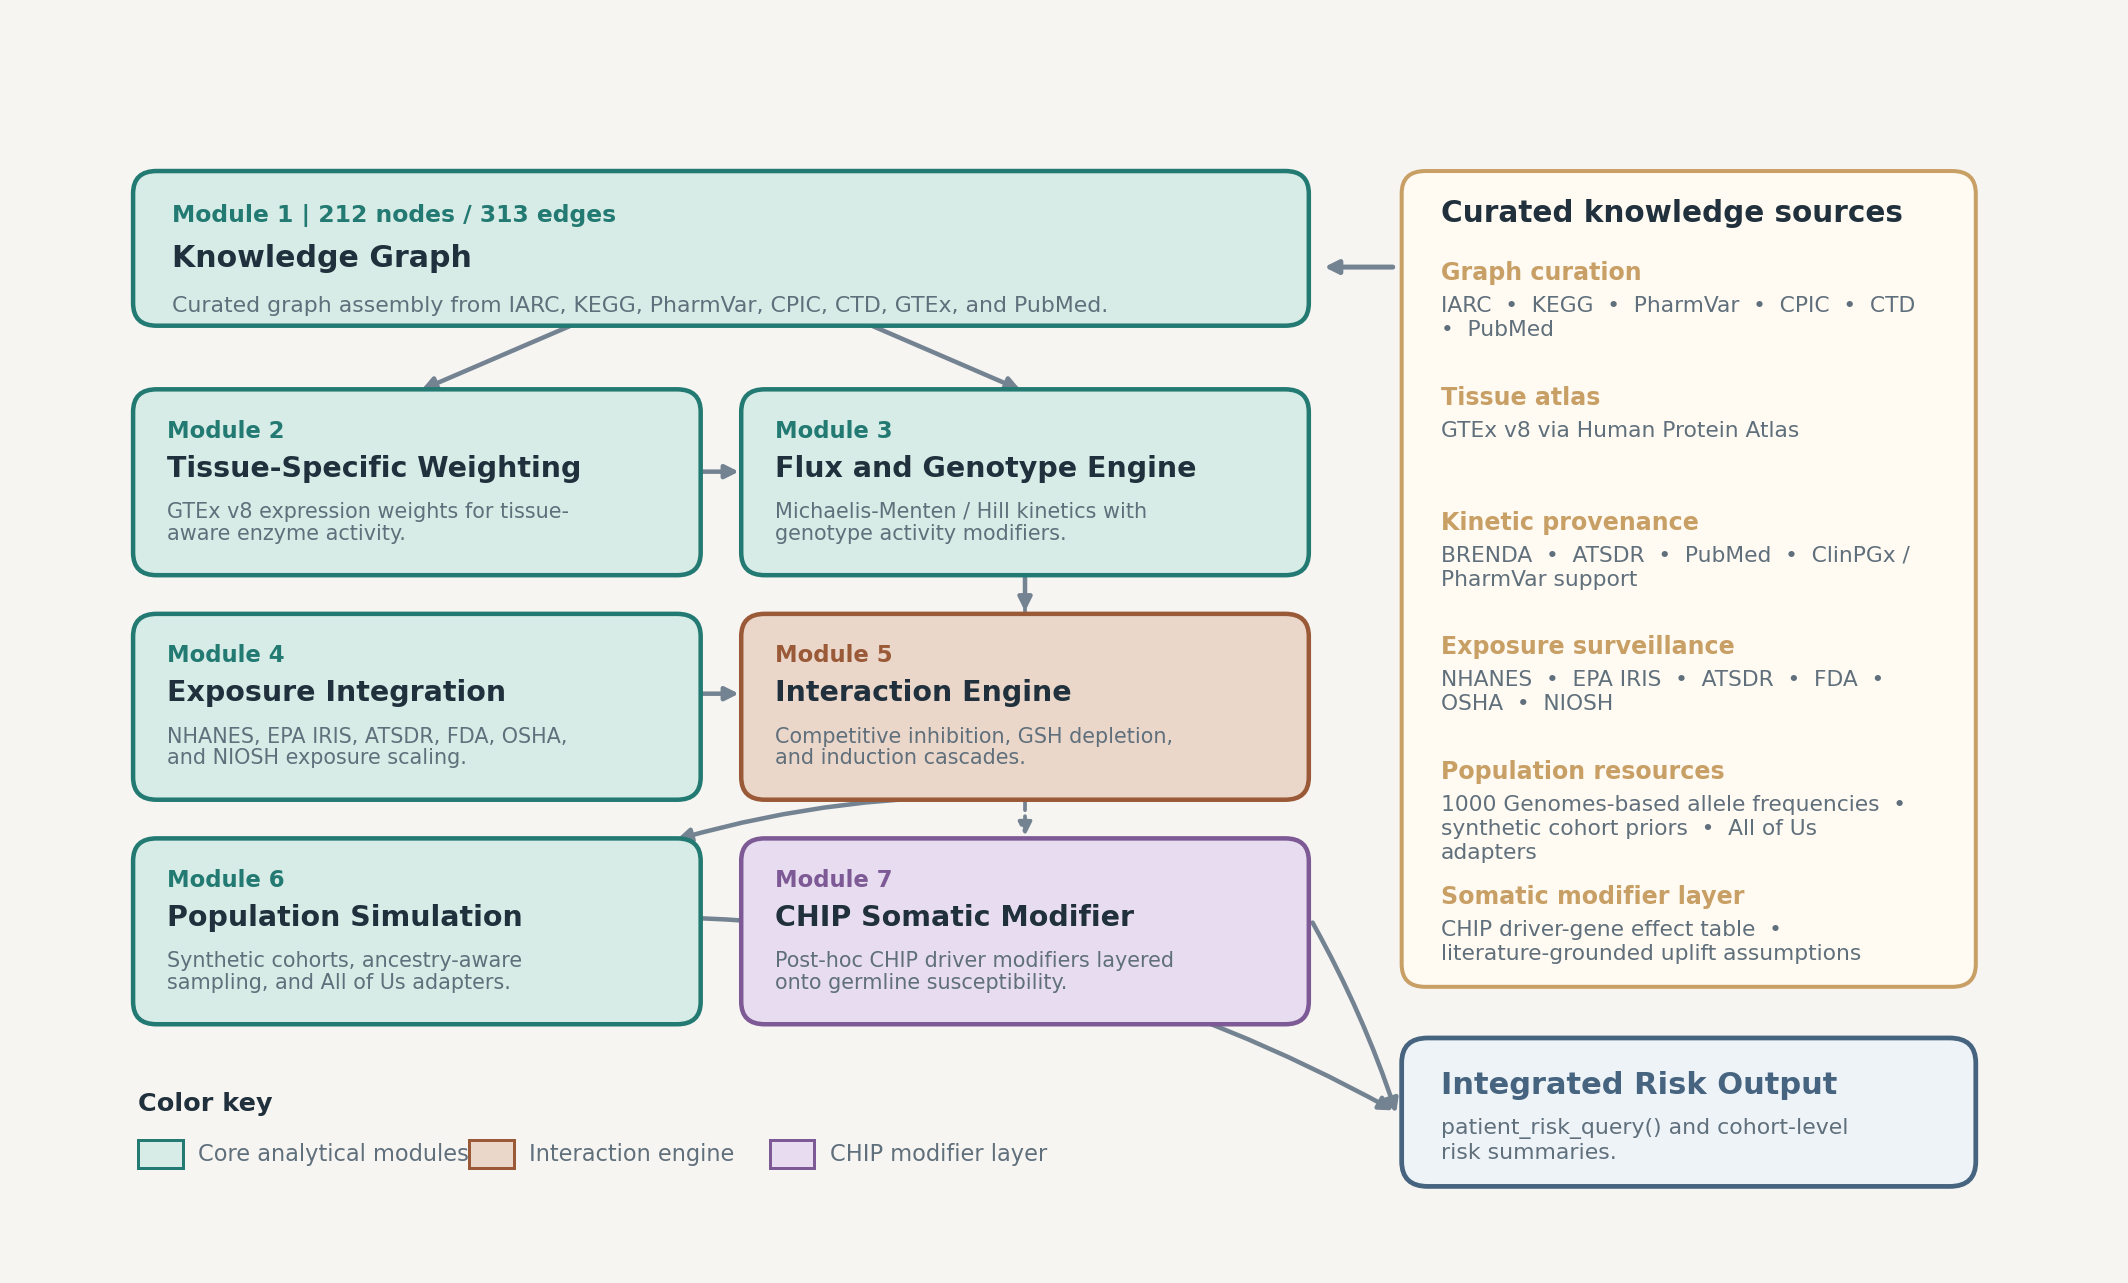

Saved /Users/julhashkazi/Documents/ExposoGraph_work/manuscript/figures/Figure-1-ExposoGraph-2.0-computational-architecture.png
Saved /Users/julhashkazi/Documents/ExposoGraph_work/manuscript/figures/Figure-1-ExposoGraph-2.0-computational-architecture.svg


In [8]:
palette = {
    "bg": "#f7f5f2",
    "ink": "#20303c",
    "muted": "#5f6f7b",
    "teal_face": "#d8ece7",
    "teal_edge": "#237a73",
    "terra_face": "#ead7ca",
    "terra_edge": "#9a5a37",
    "mauve_face": "#e8ddf0",
    "mauve_edge": "#7d5a95",
    "source_face": "#fffaf2",
    "source_edge": "#c89f65",
    "output_face": "#eef3f8",
    "output_edge": "#46647f",
    "arrow": "#748392",
}

fig, ax = plt.subplots(figsize=(15, 9), dpi=180)
fig.patch.set_facecolor(palette["bg"])
ax.set_facecolor(palette["bg"])
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")


def rounded_box(x, y, w, h, face, edge, lw=1.8, radius=0.18):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=f"round,pad=0.02,rounding_size={radius}",
        facecolor=face,
        edgecolor=edge,
        linewidth=lw,
    )
    ax.add_patch(patch)
    return patch


def add_module(x, y, w, h, title, body, badge, face, edge, body_width):
    rounded_box(x, y, w, h, face, edge)
    compact = w <= 4.5
    text_x = x + (0.24 if compact else 0.28)
    badge_size = 9.1 if compact else 9.4
    title_size = 11.4 if compact else 12
    body_size = 8.3 if compact else 8.8
    body_wrap = body_width + 4 if compact else body_width
    body_spacing = 1.12 if compact else 1.22
    ax.text(
        text_x,
        y + h - (0.22 if compact else 0.24),
        badge,
        fontsize=badge_size,
        fontweight="bold",
        color=edge,
        va="top",
        ha="left",
    )
    ax.text(
        text_x,
        y + h - (0.5 if compact else 0.56),
        title,
        fontsize=title_size,
        fontweight="bold",
        color=palette["ink"],
        va="top",
        ha="left",
    )
    ax.text(
        text_x,
        y + h - (0.88 if compact else 0.98),
        fill(body, body_wrap),
        fontsize=body_size,
        color=palette["muted"],
        va="top",
        ha="left",
        linespacing=body_spacing,
    )


def add_arrow(start, end, color=None, rad=0.0, lw=1.8, ls="-"):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=lw,
        linestyle=ls,
        color=color or palette["arrow"],
        connectionstyle=f"arc3,rad={rad}",
    )
    ax.add_patch(patch)

'''
ax.text(
    0.8,
    9.55,
    f"Seven-module pipeline from curated sources to integrated risk output. Reference graph: {summary.node_count} nodes / {summary.edge_count} edges.",
    fontsize=10.1,
    color=palette["muted"],
    ha="left",
    va="top",
)
'''
# Draw connectors first so the boxes and labels remain visually dominant.
add_arrow((10.55, 8.0), (9.95, 8.0), lw=2.0)
add_arrow((5.38, 8.05), (3.05, 7.0))
add_arrow((5.38, 8.05), (7.7, 7.0))
add_arrow((5.2, 6.36), (5.55, 6.36))
add_arrow((7.7, 5.55), (7.7, 5.2))
add_arrow((5.2, 4.58), (5.55, 4.58))
add_arrow((7.65, 3.75), (5.0, 3.4), rad=0.08)
add_arrow((5.2, 2.78), (10.55, 1.22), rad=-0.12)
add_arrow((9.88, 2.78), (10.55, 1.18), rad=-0.05)
add_arrow((7.7, 5.55), (7.7, 3.4), lw=1.5, ls="--")

add_module(
    0.9,
    7.55,
    8.95,
    1.2,
    "Knowledge Graph",
    "Curated graph assembly from IARC, KEGG, PharmVar, CPIC, CTD, GTEx, and PubMed.",
    f"Module 1 | {summary.node_count} nodes / {summary.edge_count} edges",
    palette["teal_face"],
    palette["teal_edge"],
    82,
)
add_module(
    0.9,
    5.55,
    4.3,
    1.45,
    "Tissue-Specific Weighting",
    "GTEx v8 expression weights for tissue-aware enzyme activity.",
    "Module 2",
    palette["teal_face"],
    palette["teal_edge"],
    34,
)
add_module(
    5.55,
    5.55,
    4.3,
    1.45,
    "Flux and Genotype Engine",
    "Michaelis-Menten / Hill kinetics with genotype activity modifiers.",
    "Module 3",
    palette["teal_face"],
    palette["teal_edge"],
    34,
)
add_module(
    0.9,
    3.75,
    4.3,
    1.45,
    "Exposure Integration",
    "NHANES, EPA IRIS, ATSDR, FDA, OSHA, and NIOSH exposure scaling.",
    "Module 4",
    palette["teal_face"],
    palette["teal_edge"],
    34,
)
add_module(
    5.55,
    3.75,
    4.3,
    1.45,
    "Interaction Engine",
    "Competitive inhibition, GSH depletion, and induction cascades.",
    "Module 5",
    palette["terra_face"],
    palette["terra_edge"],
    34,
)
add_module(
    0.9,
    1.95,
    4.3,
    1.45,
    "Population Simulation",
    "Synthetic cohorts, ancestry-aware sampling, and All of Us adapters.",
    "Module 6",
    palette["teal_face"],
    palette["teal_edge"],
    34,
)
add_module(
    5.55,
    1.95,
    4.3,
    1.45,
    "CHIP Somatic Modifier",
    "Post-hoc CHIP driver modifiers layered onto germline susceptibility.",
    "Module 7",
    palette["mauve_face"],
    palette["mauve_edge"],
    34,
)

rounded_box(10.6, 2.25, 4.35, 6.5, palette["source_face"], palette["source_edge"], lw=1.6, radius=0.18)
ax.text(
    10.88,
    8.55,
    "Curated knowledge sources",
    fontsize=11.8,
    fontweight="bold",
    color=palette["ink"],
    ha="left",
    va="top",
)

source_lines = [
    ("Graph curation", "IARC  •  KEGG  •  PharmVar  •  CPIC  •  CTD  •  PubMed"),
    ("Tissue atlas", "GTEx v8 via Human Protein Atlas"),
    ("Kinetic provenance", "BRENDA  •  ATSDR  •  PubMed  •  ClinPGx / PharmVar support"),
    ("Exposure surveillance", "NHANES  •  EPA IRIS  •  ATSDR  •  FDA  •  OSHA  •  NIOSH"),
    ("Population resources", "1000 Genomes-based allele frequencies  •  synthetic cohort priors  •  All of Us adapters"),
    ("Somatic modifier layer", "CHIP driver-gene effect table  •  literature-grounded uplift assumptions"),
]

y = 8.05
for title, text in source_lines:
    ax.text(
        10.88,
        y,
        title,
        fontsize=9.5,
        fontweight="bold",
        color=palette["source_edge"],
        ha="left",
        va="top",
    )
    ax.text(
        10.88,
        y - 0.28,
        fill(text, 44),
        fontsize=8.7,
        color=palette["muted"],
        ha="left",
        va="top",
        linespacing=1.25,
    )
    y -= 1.0

rounded_box(10.6, 0.65, 4.35, 1.15, palette["output_face"], palette["output_edge"], lw=1.9, radius=0.2)
ax.text(
    10.88,
    1.56,
    "Integrated Risk Output",
    fontsize=12.2,
    fontweight="bold",
    color=palette["output_edge"],
    ha="left",
    va="top",
)
ax.text(
    10.88,
    1.18,
    fill("patient_risk_query() and cohort-level risk summaries.", 40),
    fontsize=8.8,
    color=palette["muted"],
    ha="left",
    va="top",
    linespacing=1.22,
)

ax.text(0.92, 1.2, "Color key", fontsize=10.2, fontweight="bold", color=palette["ink"], ha="left", va="bottom")
for x, face, edge, label in [
    (0.92, palette["teal_face"], palette["teal_edge"], "Core analytical modules"),
    (3.45, palette["terra_face"], palette["terra_edge"], "Interaction engine"),
    (5.75, palette["mauve_face"], palette["mauve_edge"], "CHIP modifier layer"),
]:
    ax.add_patch(Rectangle((x, 0.78), 0.34, 0.22, facecolor=face, edgecolor=edge, linewidth=1.2))
    ax.text(x + 0.46, 0.89, label, fontsize=9.0, color=palette["muted"], ha="left", va="center")

png_path = output_dir / "Figure-1-ExposoGraph-2.0-computational-architecture.png"
svg_path = output_dir / "Figure-1-ExposoGraph-2.0-computational-architecture.svg"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

plt.show()
print(f"Saved {png_path}")
print(f"Saved {svg_path}")


**Caption draft**

Figure 1. ExposoGraph 2.0 computational architecture. Seven-module pipeline showing data flow from curated graph construction through tissue-specific weighting, genotype-aware flux modeling, exposure integration, interaction modeling, population simulation, and CHIP-based somatic modification to integrated risk output. Curated knowledge sources represented in the current implementation include IARC, KEGG, PharmVar, CPIC, CTD, PubMed, and GTEx-derived tissue context via Human Protein Atlas; kinetic and exposure modules incorporate BRENDA, ATSDR, NHANES, EPA IRIS, FDA, OSHA, and NIOSH support, while population and somatic-modifier layers use 1000 Genomes-based allele frequencies, synthetic cohort priors, All of Us adapters, and literature-grounded CHIP assumptions.

ExposoGraph 2.0 computational architecture. Seven-module pipeline showing data flow from curated graph construction through tissue-specific weighting, genotype-aware flux modeling, exposure integration, interaction modeling, population simulation, and CHIP-based somatic modification to integrated risk output. Curated knowledge sources represented in the current codebase include IARC, KEGG, PharmVar, CPIC, CTD, PubMed, and GTEx-derived tissue context via Human Protein Atlas, together with exposure-reference, kinetic-provenance, population-simulation, and literature-grounded somatic modifier layers.
